# Dataset Exploration: output.csv
Using `exp_parameters` as the group identifier.

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import operator as op
warnings.filterwarnings('ignore')

df = pd.read_csv('output_31-05-2026_15-54-03.csv')
df_temp = pd.read_csv('output_18-06-2026_13-47-01.csv')
df = pd.concat([df, df_temp], ignore_index=True)

df['exp_parameters'] = df['exp_parameters'].astype(str).str.strip()

word_count = df['exp_parameters'].str.split().str.len()

df.loc[word_count == 1, 'exp_parameters'] = df['exp_parameters'] + ' default'

print(f'Shape: {df.shape}')
df.head(3)

Shape: (13500, 49)


,exp_parameters,dl_capacity,ul_capacity,dl_delay,ul_delay,id,mad,mnp,mps,p,...,final_rpm_trimmed,ub_base_rpm_p,ub_base_rpm_trimmed,base_rpm_p,base_rpm_trimmed,wc_effect_p,wc_effect_trimmed,iteration,inc,inp
0,VDSL mps,100,40,5,5,1,4,16,60,90,...,747,5442,5571,5442,5574,3,13,79,NaN,NaN
1,VDSL mps,100,40,5,5,1,4,16,60,90,...,765,5433,5563,5438,5561,4,14,50,NaN,NaN
2,VDSL mps,100,40,5,5,1,4,16,60,90,...,666,5443,5566,5453,5568,3,12,23,NaN,NaN


In [2]:

rpm_cols = [c for c in df.columns if 'rpm' in c.lower()]

fieldnames = ['exp_parameters']
environment_parameters = ['dl_capacity', 'ul_capacity', 'dl_delay', 'ul_delay']

rpm_parameters = ['id', 'inc', 'inp', 'mad', 'mnp', 'mps', 'p', 'ptc', 'sdt', 'timeout', 'tmp']

dl_test_output = ['dl_stable_throughput', 'dl_stable_responsiveness', 'dl_throughput', 'dl_connections',
                   'dl_max_path_mtu', 'dl_max_send_mss', 'dl_max_recv_mss', 'dl_retransmissions',
                   'dl_reorder', 'dl_avg_rtt', 'dl_rpm_p', 'dl_rpm_trimmed']

ul_test_output = ['ul_stable_throughput', 'ul_stable_responsiveness', 'ul_throughput', 'ul_connections',
                   'ul_max_path_mtu', 'ul_max_send_mss', 'ul_max_recv_mss', 'ul_retransmissions',
                   'ul_reorder', 'ul_avg_rtt', 'ul_rpm_p', 'ul_rpm_trimmed']

final_test_output = ['final_rpm_p', 'final_rpm_trimmed']

relative_test_output = ['ub_base_rpm_p', 'ub_base_rpm_trimmed', 'base_rpm_p', 'base_rpm_trimmed',
                         'wc_effect_p', 'wc_effect_trimmed']

outputs = dl_test_output + ul_test_output + final_test_output + relative_test_output

not_relevant = ["mtu", "mss"]

outputs_for_plots = [
    item for item in outputs 
    if not any(sub in item for sub in not_relevant)
]


bool_cols = ['dl_stable_throughput', 'dl_stable_responsiveness',
             'ul_stable_throughput', 'ul_stable_responsiveness']

relevant_parameters = ['connectionsPerInterval', 'connectionsInitial', 'movingAverageDistance', 'maxParallelConnections', 
                       'probesPerSecond', 'percentageOfResults', 'capacityOfProbes', 'stabilityCutoff', 'calculationTime']
for c in bool_cols:
    if c in df.columns and df[c].dtype == object:
        df[c] = df[c].map({'True': True, 'False': False})

environments = ['VDSL', 'Cable', 'Fiber']

# rename the parameters to something readable:
rename_map = {
    'id': 'intervalDuration',
    'inc': 'connectionsPerInterval', 
    'inp': 'connectionsInitial', 
    'mad': 'movingAverageDistance', 
    'mnp': 'maxParallelConnections', 
    'mps': 'probesPerSecond', 
    'p': 'percentageOfResults', 
    'ptc': 'capacityOfProbes', 
    'sdt': 'stabilityCutoff', 
    'timeout': 'calculationTime',
    'tmp': 'trimPercentage'
}

df = df.rename(columns=rename_map)
for old_name, new_name in rename_map.items():
    # '\b' ensures we match the exact word, not parts of other words
    regex_pattern = rf'\b{old_name}\b'
    
    df['exp_parameters'] = df['exp_parameters'].str.replace(regex_pattern, new_name, regex=True)

df.head()

,exp_parameters,dl_capacity,ul_capacity,dl_delay,ul_delay,intervalDuration,movingAverageDistance,maxParallelConnections,probesPerSecond,percentageOfResults,...,final_rpm_trimmed,ub_base_rpm_p,ub_base_rpm_trimmed,base_rpm_p,base_rpm_trimmed,wc_effect_p,wc_effect_trimmed,iteration,connectionsPerInterval,connectionsInitial
0,VDSL probesPerSecond,100,40,5,5,1,4,16,60,90,...,747,5442,5571,5442,5574,3,13,79,NaN,NaN
1,VDSL probesPerSecond,100,40,5,5,1,4,16,60,90,...,765,5433,5563,5438,5561,4,14,50,NaN,NaN
2,VDSL probesPerSecond,100,40,5,5,1,4,16,60,90,...,666,5443,5566,5453,5568,3,12,23,NaN,NaN
3,VDSL probesPerSecond,100,40,5,5,1,4,16,60,90,...,748,5448,5577,5457,5579,3,13,68,NaN,NaN
4,VDSL probesPerSecond,100,40,5,5,1,4,16,60,90,...,766,5447,5574,5454,5577,3,14,92,NaN,NaN


## 1. Invalid Test results

In [3]:
is_nan = df[rpm_cols].isna()
is_inf = df[rpm_cols].isin([np.inf, -np.inf])

invalid_rpm = is_nan | is_inf

unclean_df = df[invalid_rpm.any(axis=1)]

invalid_counts = unclean_df['exp_parameters'].value_counts()
total_counts = df['exp_parameters'].value_counts()

summary_df = pd.DataFrame({
    'invalid_rows': invalid_counts,
    'total_rows': total_counts
}).fillna(0).astype(int).reset_index()

summary_df = summary_df[summary_df['invalid_rows'] > 0]

summary_df = summary_df.rename(columns={'index': 'exp_parameters'})
summary_df['percentage'] = (summary_df['invalid_rows'] / summary_df['total_rows']).map('{:.2%}'.format)
summary_df = summary_df.sort_values(by='percentage', ascending=False).reset_index(drop=True)


# 7. Sort it to match your expected format (optional)


print(summary_df)

                  exp_parameters  invalid_rows  total_rows percentage
0           VDSL stabilityCutoff            27         500      5.40%
1       VDSL percentageOfResults            42         800      5.25%
2         Cable capacityOfProbes            12         300      4.00%
3          VDSL capacityOfProbes            11         300      3.67%
4          Cable calculationTime            14         400      3.50%
5   Cable maxParallelConnections            12         400      3.00%
6           VDSL probesPerSecond            23         800      2.88%
7     VDSL movingAverageDistance            11         400      2.75%
8           VDSL calculationTime            11         400      2.75%
9    Cable movingAverageDistance            11         400      2.75%
10      Cable connectionsInitial            11         400      2.75%
11         Cable probesPerSecond            19         800      2.38%
12         Cable stabilityCutoff            10         500      2.00%
13         Fiber cal

## At which parameter did these errors occur?

In [4]:
# 1. Extract just the second word (the parameter or 'default') into a temporary column
unclean_df['clean_param'] = unclean_df['exp_parameters'].str.split().str[1]
df['clean_param'] = df['exp_parameters'].str.split().str[1]

# 2. Combine the value counts into your summary DataFrame
summary_df = pd.DataFrame({
    'invalid_rows': unclean_df['clean_param'].value_counts(),
    'total_rows': df['clean_param'].value_counts()
}).fillna(0).astype(int)

unclean_df = unclean_df.drop(columns=['clean_param'])
df = df.drop(columns=['clean_param'])

# 3. Filter out rows with 0 invalid records and reset the index
summary_df = summary_df[summary_df['invalid_rows'] > 0].reset_index()
summary_df = summary_df.rename(columns={'index': 'exp_parameter'})

# 4. Calculate the failure percentage and sort by the highest number of invalid rows
summary_df = summary_df.sort_values(by='invalid_rows', ascending=False).reset_index(drop=True)
summary_df['percentage'] = (summary_df['invalid_rows'] / summary_df['total_rows']).map('{:.2%}'.format)

# Render the final table
print(summary_df)

              clean_param  invalid_rows  total_rows percentage
0     percentageOfResults            58        2400      2.42%
1         probesPerSecond            45        2400      1.88%
2         stabilityCutoff            38        1500      2.53%
3         calculationTime            32        1200      2.67%
4   movingAverageDistance            26        1200      2.17%
5        capacityOfProbes            23         900      2.56%
6  maxParallelConnections            19        1200      1.58%
7      connectionsInitial            17        1200      1.42%
8  connectionsPerInterval             5        1200      0.42%
9                 default             1         300      0.33%


## heatmap

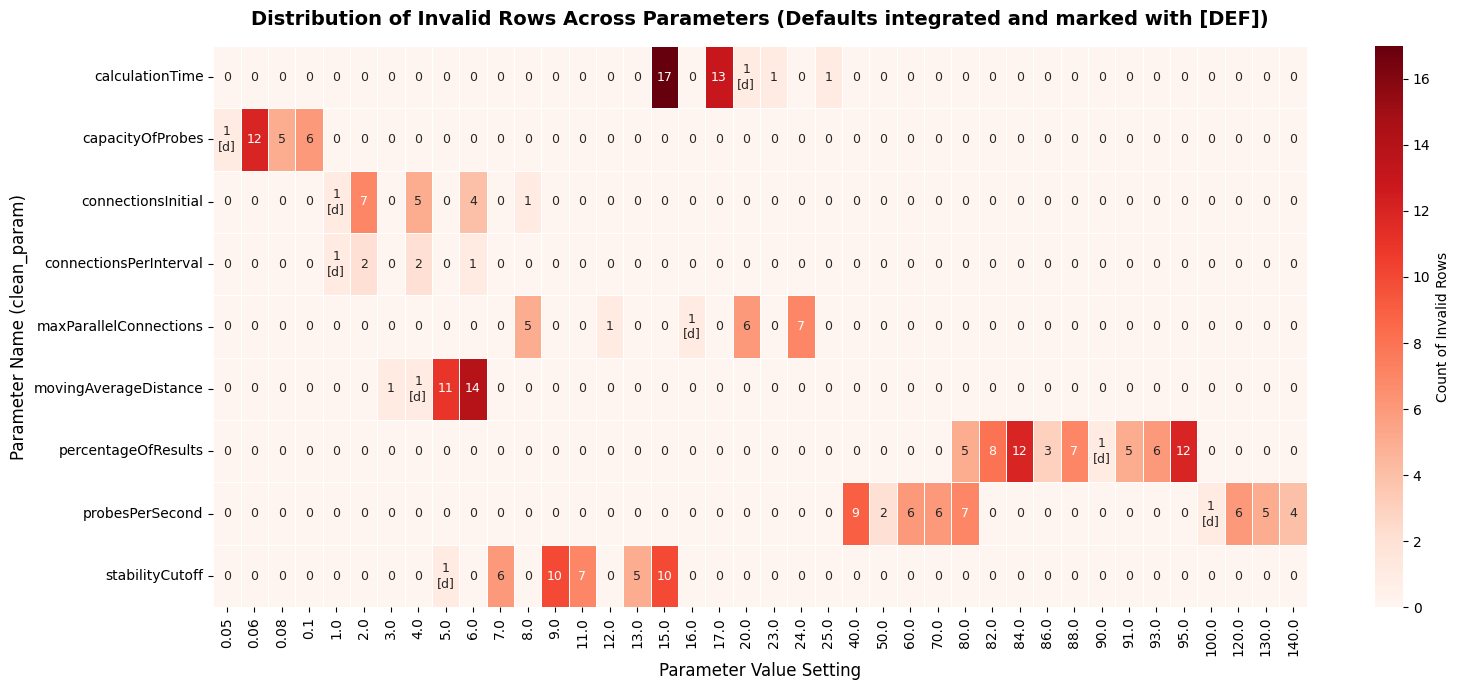

In [5]:
# ==============================================================================
# STEP 1: DEFINE DEFAULT MAPPINGS
# ==============================================================================
default_values = {
    'connectionsPerInterval': 1,
    'connectionsInitial': 1,
    'movingAverageDistance': 4,
    'maxParallelConnections': 16,
    'probesPerSecond': 100,
    'percentageOfResults': 90,
    'capacityOfProbes': 0.05,
    'stabilityCutoff': 5,
    'calculationTime': 20
}

# ==============================================================================
# STEP 2: EXTRACT ACTIVE PARAMETERS FROM THE DATASET
# ==============================================================================
unclean_df['clean_param'] = unclean_df['exp_parameters'].str.split().str[1]
df['clean_param'] = df['exp_parameters'].str.split().str[1]

# Gather active invalid and total profiles
summary_df = pd.DataFrame({
    'invalid_rows': unclean_df['clean_param'].value_counts(),
    'total_rows': df['clean_param'].value_counts()
}).fillna(0).astype(int)

# Strip out temporary columns immediately 
unclean_df = unclean_df.drop(columns=['clean_param'])
df = df.drop(columns=['clean_param'])

# Isolate parameters with at least 1 error row
summary_df = summary_df[summary_df['invalid_rows'] > 0].reset_index()
summary_df = summary_df.rename(columns={'index': 'clean_param'})

# ==============================================================================
# STEP 3: CONSTRUCT THE BASE GRID MATRIX
# ==============================================================================
def get_val(row):
    p_name = str(row['exp_parameters']).split()[1]
    if p_name == 'default':
        return 'default'
    return row[p_name] if p_name in row.index else None

unclean_df['clean_param'] = unclean_df['exp_parameters'].str.split().str[1]
unclean_df['Value'] = unclean_df.apply(get_val, axis=1)

# Isolate error data
heatmap_data = unclean_df[unclean_df['clean_param'].isin(summary_df['clean_param'])]

matrix_data = (
    heatmap_data.groupby(['clean_param', 'Value'], dropna=False)
    .size()
    .reset_index(name='invalid_count')
)

unclean_df = unclean_df.drop(columns=['clean_param', 'Value'])

# Pivot structural data into a 2D matrix
heatmap_matrix = matrix_data.pivot(
    index='clean_param', 
    columns='Value', 
    values='invalid_count'
).fillna(0)

# ==============================================================================
# STEP 4: DISTRIBUTE DEFAULT VALUES & CLEAN INDEX
# ==============================================================================
# 1. Grab the baseline error count from the 'default' row and 'default' column intersection
baseline_error_count = 0.0
if 'default' in heatmap_matrix.index and 'default' in heatmap_matrix.columns:
    baseline_error_count = heatmap_matrix.loc['default', 'default']

# 2. Drop the 'default' row from the Y-axis immediately
if 'default' in heatmap_matrix.index:
    heatmap_matrix = heatmap_matrix.drop(index=['default'])

# 3. Drop the 'default' column from the X-axis now that we have its value cached
if 'default' in heatmap_matrix.columns:
    heatmap_matrix = heatmap_matrix.drop(columns=['default'])

# 4. Inject the baseline count into the correct numeric default cell for each parameter
for param, def_val in default_values.items():
    if param in heatmap_matrix.index:
        # If the specific numeric column doesn't exist in the sweep layout yet, create it
        if def_val not in heatmap_matrix.columns:
            heatmap_matrix[def_val] = 0.0
        
        # Add the baseline error count to that specific parameter's default cell
        heatmap_matrix.loc[param, def_val] = baseline_error_count

# 5. Sort columns numerically so our newly inserted values fall in the correct sequence
heatmap_matrix = heatmap_matrix.reindex(sorted(heatmap_matrix.columns), axis=1)

# 6. Convert columns to string labels to guarantee smooth, unshifted plotting alignment
heatmap_matrix.columns = [str(c) for c in heatmap_matrix.columns]

# ==============================================================================
# STEP 5: GENERATE COORDINATE-ALIGNED LABELS & PLOT HEATMAP
# ==============================================================================
# Create an empty string dataframe for annotations matching our exact matrix shape
annot_matrix = pd.DataFrame("", index=heatmap_matrix.index, columns=heatmap_matrix.columns)

for row in heatmap_matrix.index:
    for col in heatmap_matrix.columns:
        val = heatmap_matrix.loc[row, col]
        
        # Safe float matching logic to check if this cell is the parameter's default configuration
        try:
            is_default_cell = (row in default_values and abs(float(col) - float(default_values[row])) < 1e-9)
        except (ValueError, TypeError, KeyError):
            is_default_cell = False
            
        if is_default_cell:
            annot_matrix.loc[row, col] = f"{val:.0f}\n[d]"
        else:
            annot_matrix.loc[row, col] = f"{val:.0f}" if val > 0 else "0"

# Generate the plot
plt.figure(figsize=(16, 7))

sns.heatmap(
    heatmap_matrix, 
    annot=annot_matrix.values,  # Pass raw values array to eliminate pandas index misalignment bugs
    fmt="",                     # Dictates using our formatted strings directly
    cmap='Reds', 
    linewidths=0.5,
    cbar_kws={'label': 'Count of Invalid Rows'},
    annot_kws={'fontsize': 9}   # Slightly smaller font to allow text labels to sit beautifully
)

plt.title('Distribution of Invalid Rows Across Parameters (Defaults integrated and marked with [DEF])', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Parameter Value Setting', fontsize=12)
plt.ylabel('Parameter Name (clean_param)', fontsize=12)

plt.tight_layout()
plt.show()

- Default test is the most stable (when it comes to invalid data)
- The 'p' parameter seems to be most affected, BUT the range is higher so there will be more 'p' data than other parameters

## In which network did these errors occur?

In [6]:
# 1. Extract just the second word (the parameter or 'default') into a temporary column
unclean_df['clean_net'] = unclean_df['exp_parameters'].str.split().str[0]
df['clean_net'] = df['exp_parameters'].str.split().str[0]

# 2. Combine the value counts into your summary DataFrame
summary_df = pd.DataFrame({
    'invalid_rows': unclean_df['clean_net'].value_counts(),
    'total_rows': df['clean_net'].value_counts()
}).fillna(0).astype(int)

unclean_df = unclean_df.drop(columns=['clean_net'])
df = df.drop(columns=['clean_net'])

# 3. Filter out rows with 0 invalid records and reset the index
summary_df = summary_df[summary_df['invalid_rows'] > 0].reset_index()
summary_df = summary_df.rename(columns={'index': 'exp_parameter'})

# 4. Calculate the failure percentage and sort by the highest number of invalid rows
summary_df = summary_df.sort_values(by='invalid_rows', ascending=False).reset_index(drop=True)
summary_df['percentage'] = (summary_df['invalid_rows'] / summary_df['total_rows']).map('{:.2%}'.format)

# Render the final table
print(summary_df)

  clean_net  invalid_rows  total_rows percentage
0      VDSL           140        4500      3.11%
1     Cable           107        4500      2.38%
2     Fiber            17        4500      0.38%


## 2. One dimensional test (Environment)

## Environments

In [7]:

is_nan = df[rpm_cols].isna()
is_inf = df[rpm_cols].isin([np.inf, -np.inf])
invalid_rpm = is_nan | is_inf

df_clean = df[~invalid_rpm.any(axis=1)].copy()

df_clean = df_clean.reset_index(drop=True)

print(f"Original DataFrame rows: {len(df)}")
print(f"Cleaned DataFrame rows:  {len(df_clean)}")
print(f"Successfully removed:    {len(df) - len(df_clean)} invalid rows.")

Original DataFrame rows: 13500
Cleaned DataFrame rows:  13236
Successfully removed:    264 invalid rows.


## Stability

In [8]:
default_experiments = [exp for exp in df_clean['exp_parameters'].unique() if str(exp).split()[1] == 'default']
df_default = df_clean[df_clean['exp_parameters'].isin(default_experiments)].copy()

# 2. Iterate through each single-substring experiment
for exp in default_experiments:
    # Isolate rows for this specific baseline experiment
    df_exp = df_default[df_default['exp_parameters'] == exp]
    
    # Automatically identify all boolean columns in this subset
    bool_cols = df_exp.select_dtypes(include=['bool']).columns.tolist()
    
    if not bool_cols:
        print(f"No boolean parameters found for experiment: '{exp}'\n")
        continue
        
    print(f"Analysis for Baseline Experiment: '{exp}'")
    print("-" * 65)
    print(f"{'Boolean Parameter':<25} {'Total Rows':<12} {'True Count':<12} {'Percentage'}")
    print("-" * 65)
    
    # 3. Calculate metrics for each boolean column
    for col in bool_cols:
        total_rows = len(df_exp)
        true_count = df_exp[col].sum()  # Summing a boolean column counts the True values
        
        # Avoid division by zero just in case the filtered dataframe is empty
        percentage = (true_count / total_rows * 100) if total_rows > 0 else 0.0
        
        print(f"{col:<25} {total_rows:<12} {true_count:<12} {percentage:.2f}%")
    
    print("\n" + "="*65 + "\n")

Analysis for Baseline Experiment: 'VDSL default'
-----------------------------------------------------------------
Boolean Parameter         Total Rows   True Count   Percentage
-----------------------------------------------------------------
dl_stable_throughput      100          100          100.00%
dl_stable_responsiveness  100          72           72.00%
ul_stable_throughput      100          87           87.00%
ul_stable_responsiveness  100          0            0.00%


Analysis for Baseline Experiment: 'Fiber default'
-----------------------------------------------------------------
Boolean Parameter         Total Rows   True Count   Percentage
-----------------------------------------------------------------
dl_stable_throughput      100          98           98.00%
dl_stable_responsiveness  100          84           84.00%
ul_stable_throughput      100          100          100.00%
ul_stable_responsiveness  100          88           88.00%


Analysis for Baseline Experiment: 

## Numeric outputs

Found 3 single-substring baseline experiments: ['VDSL default', 'Fiber default', 'Cable default']
 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_THROUGHPUT
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       225.06     225.03     0.22       0.05        
Fiber default    100      542.56     542.54     0.28       0.08        
VDSL default     100      88.93      88.87      0.23       0.05        
---------------------------------------------------------------------------

Visual Distribution:


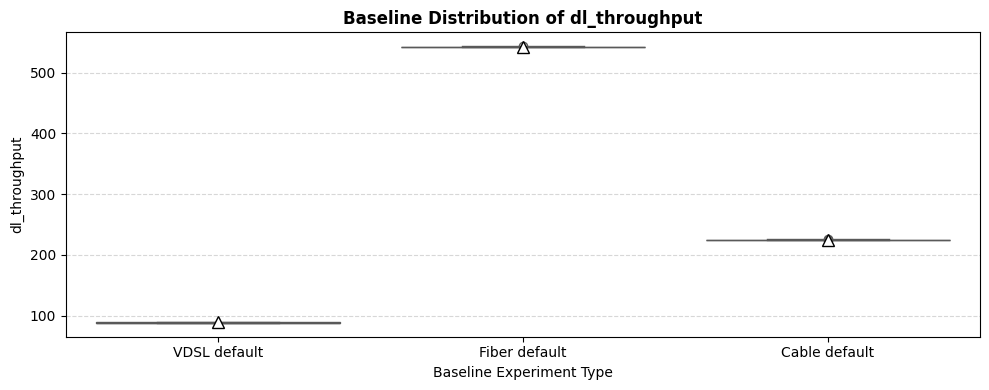


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_CONNECTIONS
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       15.72      16.00      0.88       0.78        
Fiber default    100      14.64      16.00      1.83       3.34        
VDSL default     100      15.09      16.00      1.54       2.37        
---------------------------------------------------------------------------

Visual Distribution:


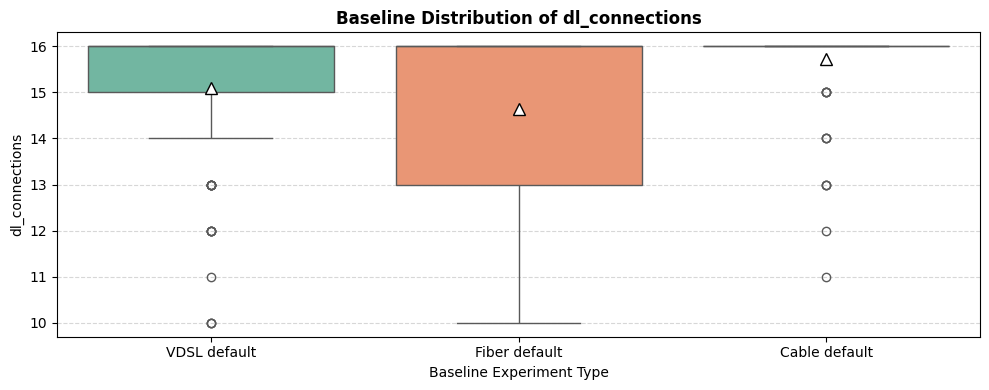


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_RETRANSMISSIONS
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       0.01       0.00       0.10       0.01        
Fiber default    100      0.08       0.00       0.27       0.07        
VDSL default     100      0.00       0.00       0.00       0.00        
---------------------------------------------------------------------------

Visual Distribution:


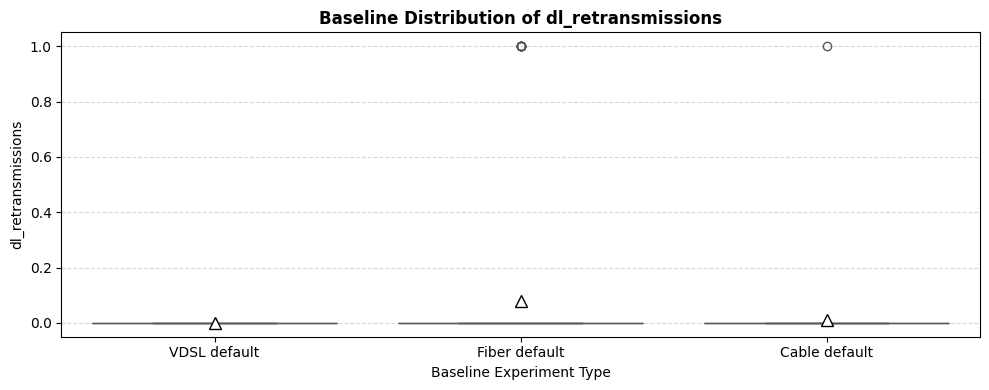


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_REORDER
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       47.39      48.00      2.18       4.77        
Fiber default    100      44.81      48.00      4.71       22.22       
VDSL default     100      46.14      48.00      3.71       13.78       
---------------------------------------------------------------------------

Visual Distribution:


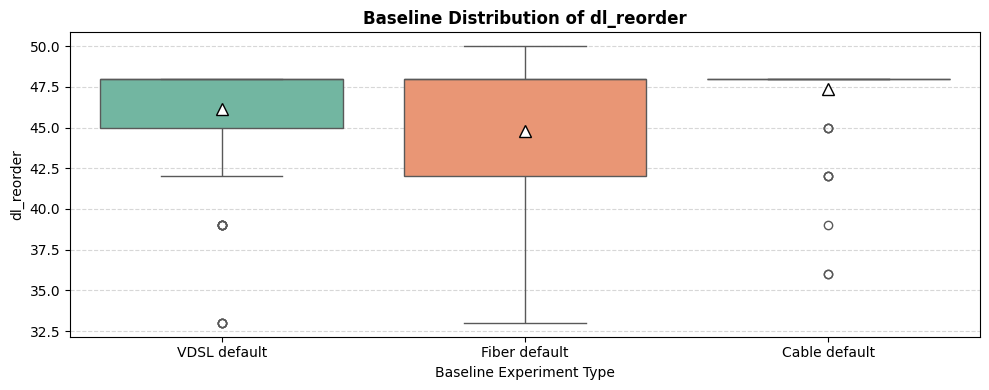


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_AVG_RTT
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       22967.82   22924.19   188.20     35419.02    
Fiber default    100      10812.00   10820.74   206.36     42586.02    
VDSL default     100      15150.64   15222.81   375.53     141025.16   
---------------------------------------------------------------------------

Visual Distribution:


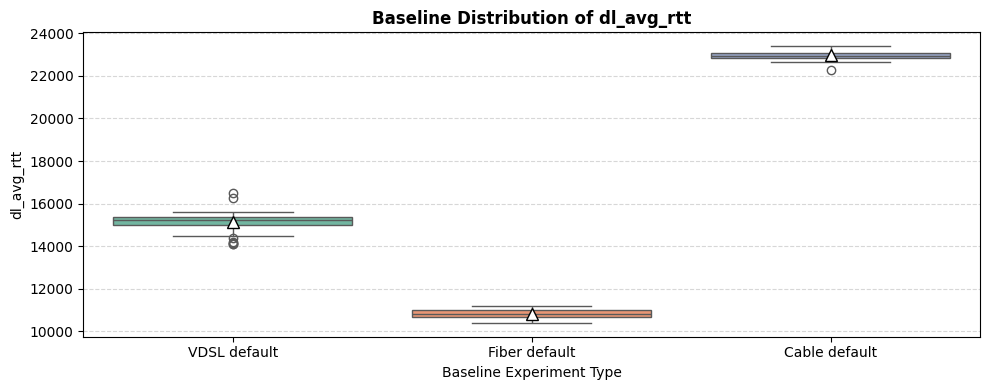


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_RPM_P
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       383.51     384.00     24.35      593.11      
Fiber default    100      744.44     739.50     75.54      5706.69     
VDSL default     100      373.93     360.00     45.80      2097.32     
---------------------------------------------------------------------------

Visual Distribution:


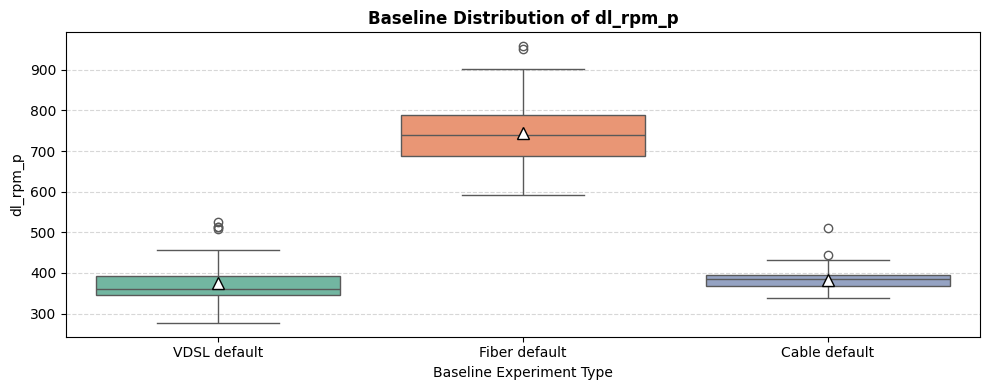


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: DL_RPM_TRIMMED
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       720.99     705.00     57.69      3328.15     
Fiber default    100      1839.01    1794.50    223.81     50091.26    
VDSL default     100      754.56     729.50     76.59      5865.52     
---------------------------------------------------------------------------

Visual Distribution:


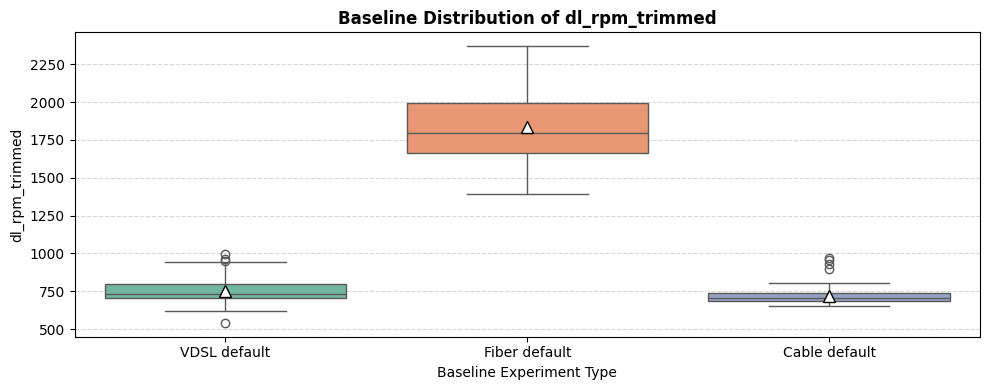


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_THROUGHPUT
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       44.29      44.33      1.05       1.10        
Fiber default    100      271.76     271.62     0.91       0.83        
VDSL default     100      35.36      35.37      0.75       0.57        
---------------------------------------------------------------------------

Visual Distribution:


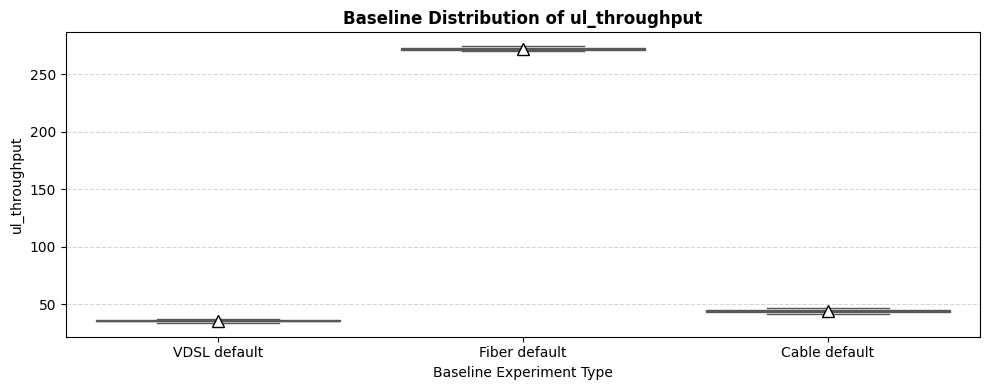


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_CONNECTIONS
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       16.00      16.00      0.00       0.00        
Fiber default    100      14.49      15.00      1.80       3.24        
VDSL default     100      16.00      16.00      0.00       0.00        
---------------------------------------------------------------------------

Visual Distribution:


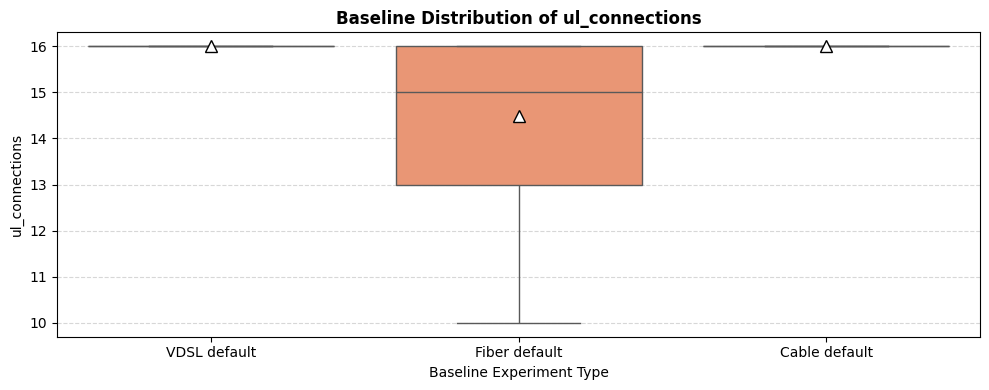


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_RETRANSMISSIONS
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       0.02       0.00       0.14       0.02        
Fiber default    100      0.27       0.00       0.55       0.30        
VDSL default     100      386.50     326.50     240.70     57938.43    
---------------------------------------------------------------------------

Visual Distribution:


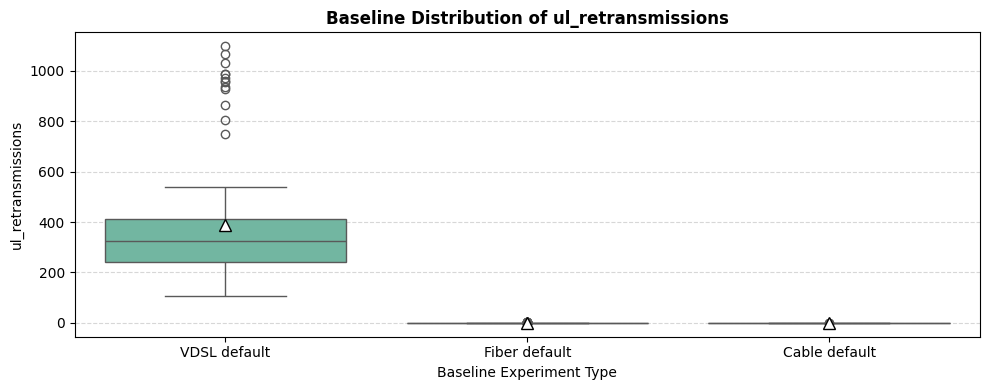


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_REORDER
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       48.32      48.00      1.14       1.30        
Fiber default    100      69.16      62.00      21.20      449.51      
VDSL default     100      48.02      48.00      0.14       0.02        
---------------------------------------------------------------------------

Visual Distribution:


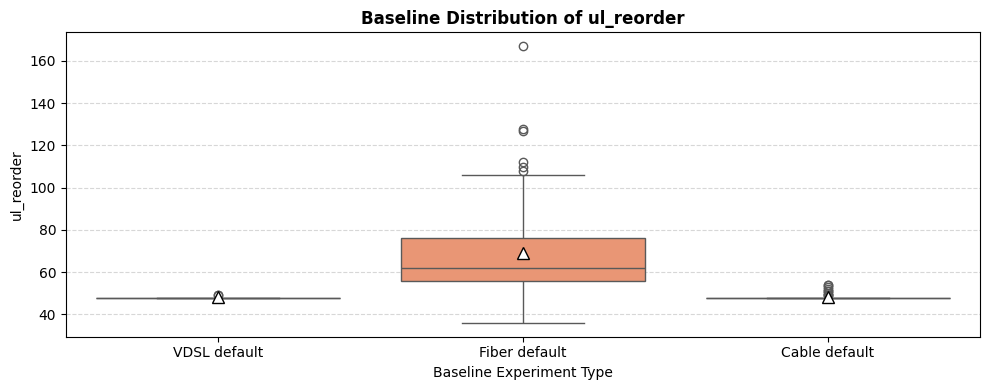


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_AVG_RTT
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       31251.47   31276.69   414.31     171649.60   
Fiber default    100      11511.98   11531.09   221.04     48856.87    
VDSL default     100      23618.68   23578.38   465.01     216230.75   
---------------------------------------------------------------------------

Visual Distribution:


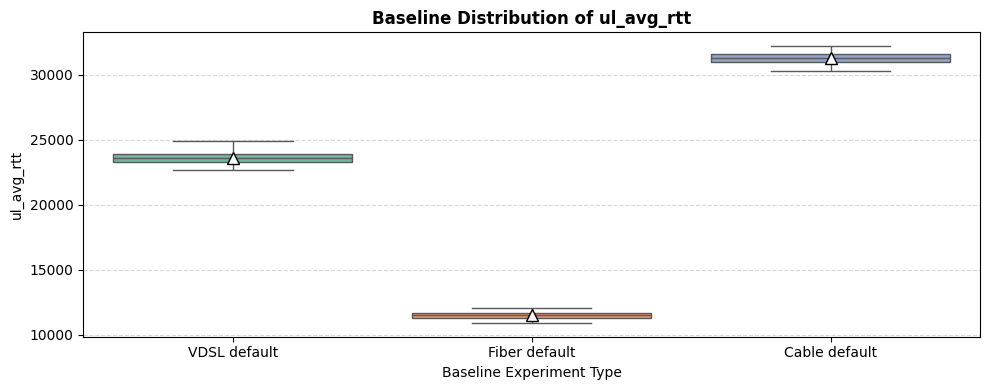


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_RPM_P
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       92.54      91.00      21.08      444.37      
Fiber default    100      640.45     630.00     77.85      6060.23     
VDSL default     100      67.82      63.00      21.46      460.51      
---------------------------------------------------------------------------

Visual Distribution:


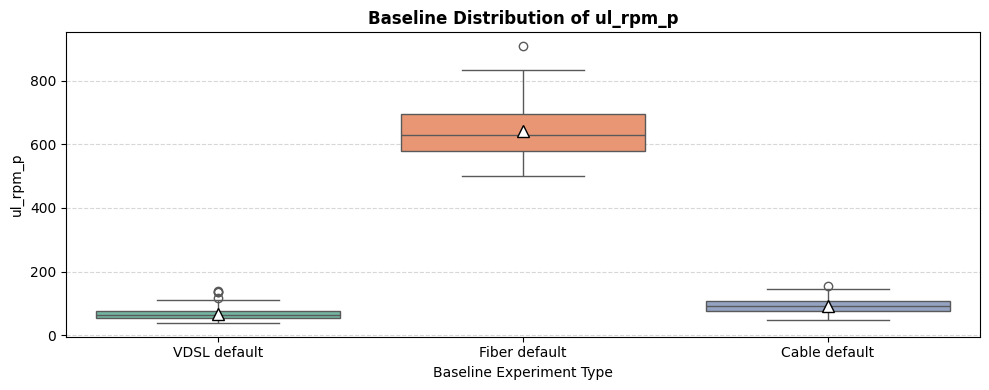


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UL_RPM_TRIMMED
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       424.88     426.00     18.41      338.92      
Fiber default    100      1679.98    1656.50    218.12     47575.27    
VDSL default     100      469.07     468.00     49.57      2457.28     
---------------------------------------------------------------------------

Visual Distribution:


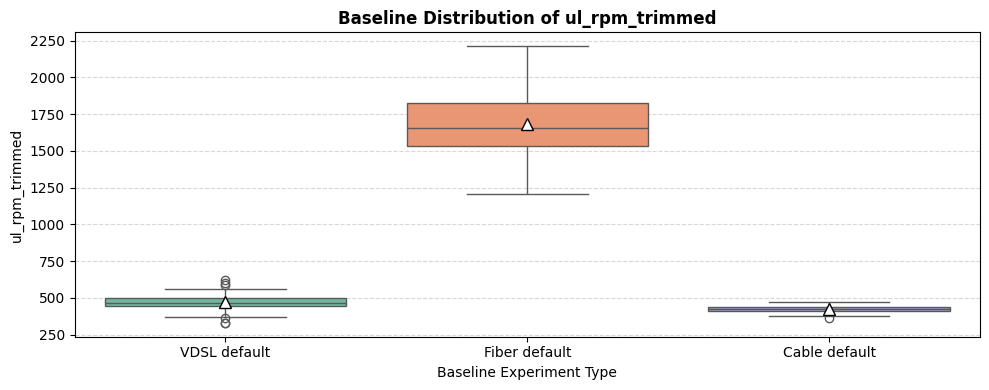


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: FINAL_RPM_P
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       125.49     109.00     57.17      3268.70     
Fiber default    100      679.40     683.50     49.67      2466.83     
VDSL default     100      90.42      78.00      44.33      1965.01     
---------------------------------------------------------------------------

Visual Distribution:


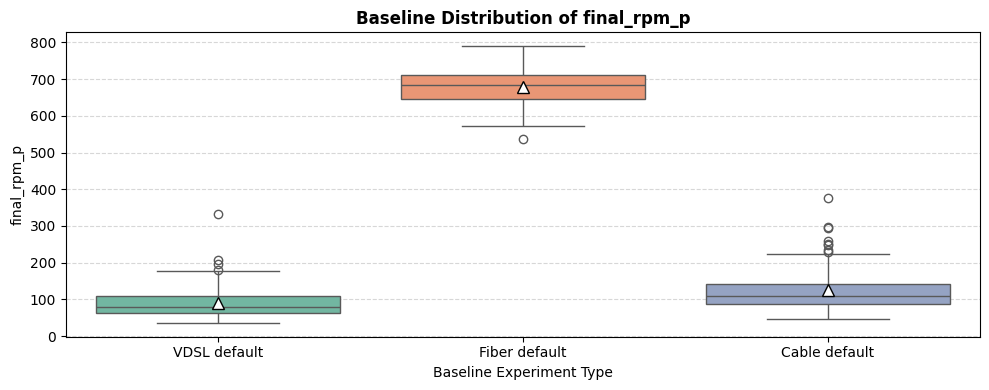


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: FINAL_RPM_TRIMMED
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       696.34     678.00     68.03      4627.60     
Fiber default    100      1833.97    1822.50    156.45     24477.34    
VDSL default     100      740.94     734.00     74.83      5598.93     
---------------------------------------------------------------------------

Visual Distribution:


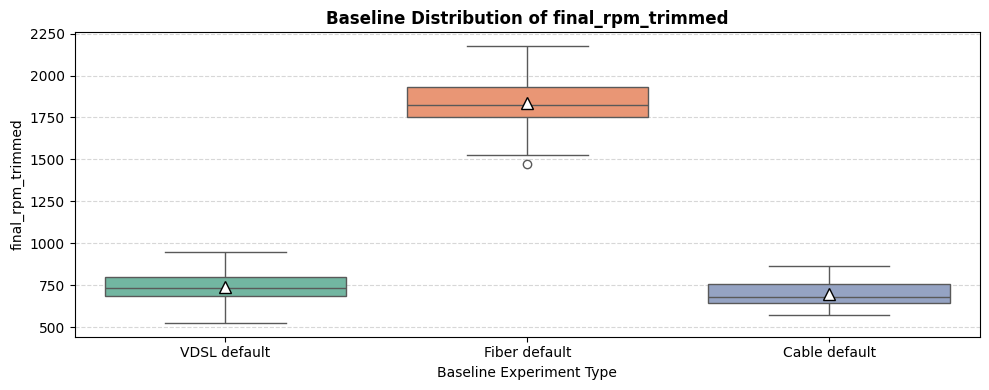


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UB_BASE_RPM_P
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       2774.51    2781.00    12.67      160.64      
Fiber default    100      6650.94    6651.00    13.72      188.12      
VDSL default     100      5444.41    5447.00    21.73      472.37      
---------------------------------------------------------------------------

Visual Distribution:


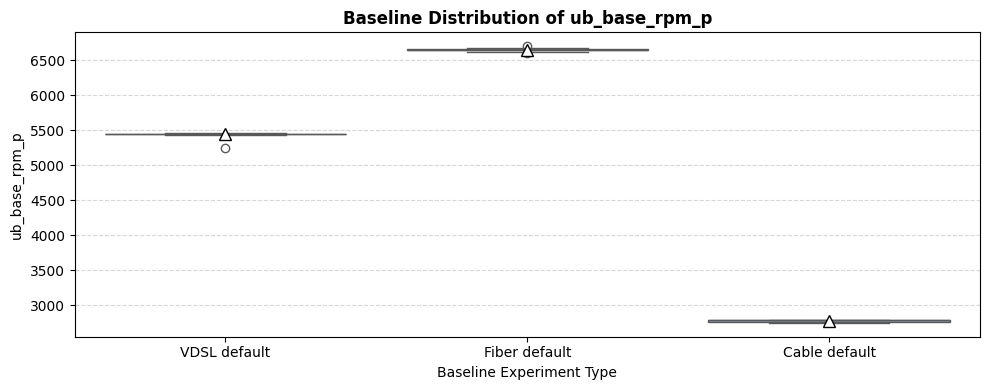


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: UB_BASE_RPM_TRIMMED
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       2845.52    2847.00    13.58      184.52      
Fiber default    100      6869.70    6868.00    12.48      155.75      
VDSL default     100      5562.88    5562.00    10.56      111.58      
---------------------------------------------------------------------------

Visual Distribution:


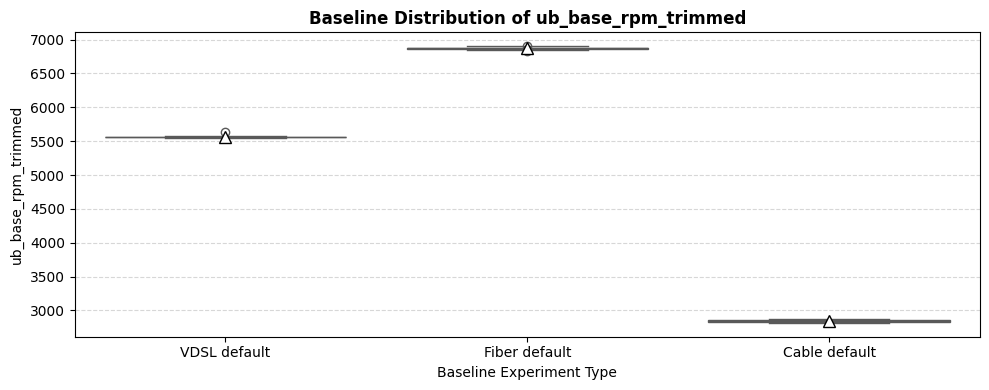


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: BASE_RPM_P
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       2773.01    2779.00    12.89      166.21      
Fiber default    100      6648.56    6647.50    16.85      283.80      
VDSL default     100      5441.00    5443.00    21.31      453.92      
---------------------------------------------------------------------------

Visual Distribution:


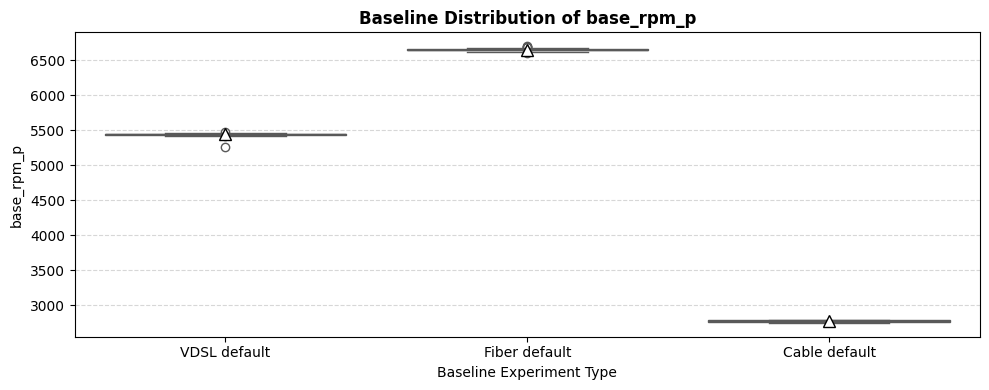


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: BASE_RPM_TRIMMED
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       2848.57    2850.00    13.76      189.37      
Fiber default    100      6871.15    6871.50    14.77      218.03      
VDSL default     100      5564.14    5563.50    11.21      125.74      
---------------------------------------------------------------------------

Visual Distribution:


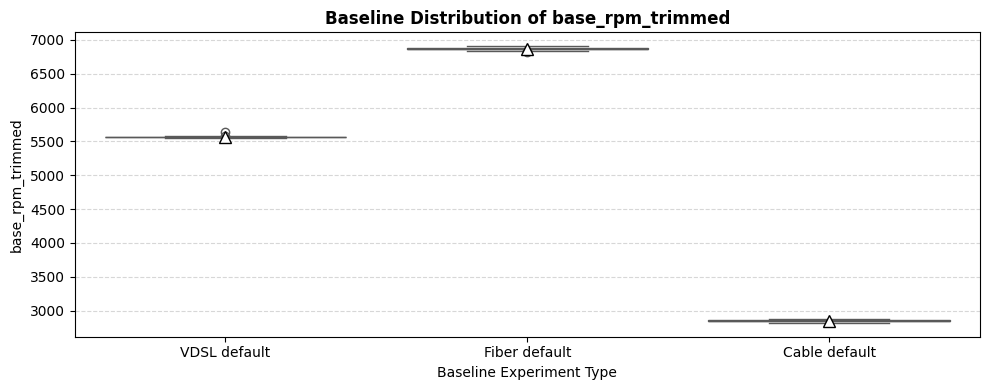


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: WC_EFFECT_P
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       4.55       4.00       2.11       4.45        
Fiber default    100      10.24      10.00      0.82       0.67        
VDSL default     100      1.62       1.00       0.86       0.74        
---------------------------------------------------------------------------

Visual Distribution:


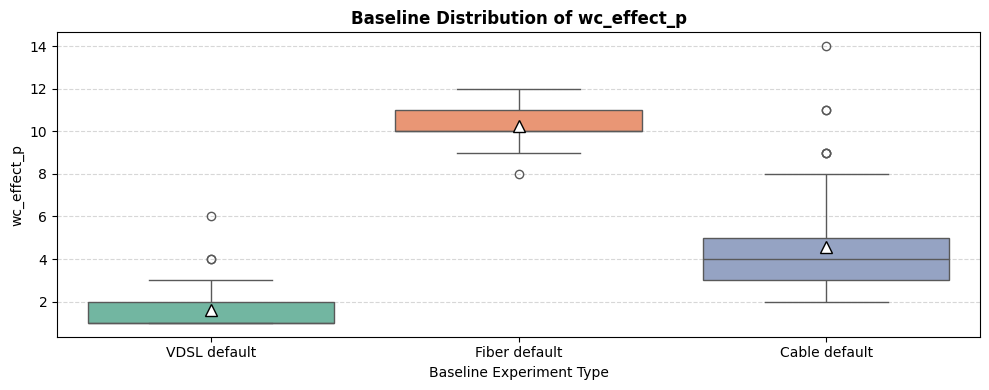


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR BASELINE METRIC: WC_EFFECT_TRIMMED
Experiment Type  Count    Mean       Median     Std Dev    Variance    
---------------------------------------------------------------------------
Cable default    99       24.48      24.00      2.38       5.68        
Fiber default    100      26.65      27.00      2.29       5.24        
VDSL default     100      13.31      13.00      1.38       1.89        
---------------------------------------------------------------------------

Visual Distribution:


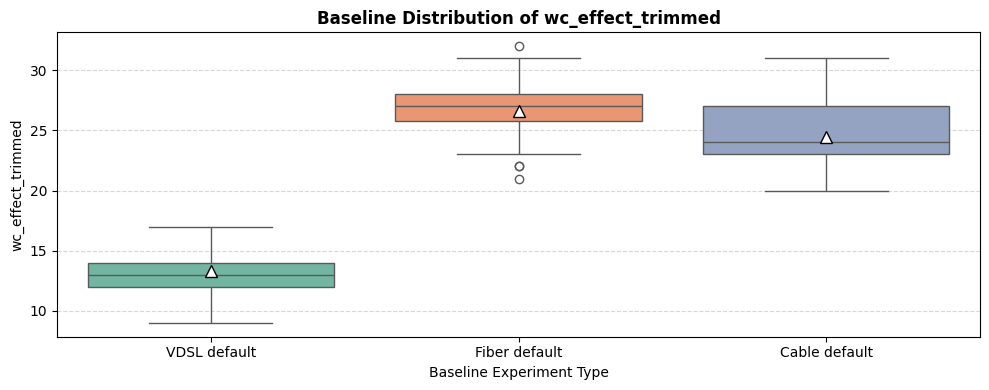


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx



In [9]:
print(f"Found {len(default_experiments)} single-substring baseline experiments: {default_experiments}")

# --- 3. MAIN BLOCK UNIFIED LOOP ---
for col in outputs_for_plots:
    # Skip if the metric is completely missing from the dataframe
    if col not in df_default.columns:
        continue
    if col in bool_cols:
        continue
        
    # Force numeric parsing to clear out any leftover object data types
    df_default[col] = pd.to_numeric(df_default[col], errors='coerce')
    
    # --- A: PRINT STATISTICAL SUMMARY TABLE ---
    print("=" * 75)
    print(f" REPORT & VISUALIZATION FOR BASELINE METRIC: {col.upper()}")
    print("=" * 75)
    print(f"{'Experiment Type':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
    print("-" * 75)
    
    # Calculate essential metrics across the single-word experiments group
    stats = df_default.groupby('exp_parameters')[col].agg([
        'count', 'mean', 'median', 'std', 'var'
    ]).reset_index()
    
    stats.columns = ['exp_parameters', 'count', 'mean', 'median', 'std', 'var']
    
    for _, row in stats.iterrows():
        print(f"{str(row['exp_parameters']):<16} "
              f"{int(row['count']):<8} "
              f"{row['mean']:<10.2f} "
              f"{row['median']:<10.2f} "
              f"{row['std']:<10.2f} "
              f"{row['var']:<12.2f}")
    print("-" * 75)
    print("\nVisual Distribution:")

    # --- B: RENDER THE CORRESPONDING BOX PLOT ---
    plt.figure(figsize=(10, 4))
    
    sns.boxplot(
        data=df_default, 
        x='exp_parameters', 
        y=col, 
        palette='Set2',
        showmeans=True,
        meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
    )
    
    plt.title(f'Baseline Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Baseline Experiment Type', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()  
    
    print("\n" + "x" * 75 + "\n")

## 3. Two dimensional  (Environment + Testparameter)

## Stability

In [14]:
all_exps = df_clean['exp_parameters'].unique()
non_default_experiments = [exp for exp in all_exps if str(exp).split()[1] != 'default']
df_default = df_clean[df_clean['exp_parameters'].isin(default_experiments)].copy()
df_non_default = df_clean[df_clean['exp_parameters'].isin(non_default_experiments)].copy()

for exp in non_default_experiments:
    net = str(exp).split()[0]
    rows_to_duplicate = df_default[df_default['exp_parameters'].str.contains(net)].copy()
    rows_to_duplicate['exp_parameters'] = exp

    df_non_default = pd.concat([df_non_default, rows_to_duplicate], ignore_index=True)

# Grouping by the unique experiment strings to find our parameter blocks
for exp in non_default_experiments:
    # 1. DYNAMICALLY EXTRACT THE PARAMETER COLUMN NAME
    tokens = str(exp).split()
    if len(tokens) < 2:
        continue
    param_column = tokens[1]
    
    if param_column not in df_non_default.columns:
        continue
        
    # 2. IDENTIFY ALL BOOLEAN COLUMNS FOR THIS PARAMETER'S ROWS
    # We slice df_non_default to find rows belonging to this parameter string family
    df_param_family = df_non_default[df_non_default['exp_parameters'] == exp]
    bool_cols = df_param_family.select_dtypes(include=['bool']).columns.tolist()
    
    if not bool_cols:
        continue
        
    print(f"Analysis for Parameter Column: '{param_column}' (Source: '{exp}')")
    print("=" * 75)
    
    # 3. GLOBAL FILTER: Find all unique values tested for this column across the entire dataset
    unique_values = sorted(df_non_default[param_column].dropna().unique())
    
    for val in unique_values:
        # Filter the original non-default dataframe based directly on this column's value
        df_val_subset = df_non_default[df_non_default[param_column] == val]
        total_rows = len(df_val_subset)
        
        if total_rows == 0:
            continue

        default_val = default_values.get(param_column)
    
        if val == default_val:
            print(f" '{param_column}' = {val} (default):")
        else:
            print(f" '{param_column}' = {val} :")
        print("-" * 75)
        print(f"    {'Boolean Parameter':<25} {'Total Rows':<12} {'True Count':<12} {'Percentage'}")
        print("-" * 75)
        
        # 4. CALCULATE METRICS FOR EACH BOOLEAN COLUMN
        for col in bool_cols:
            true_count = df_val_subset[col].sum()
            percentage = (true_count / total_rows * 100) if total_rows > 0 else 0.0
            print(f"    {col:<25} {total_rows:<12} {true_count:<12} {percentage:.2f}%")
            
        print("-" * 75 + "\n")
        
    print("=" * 75 + "\n\n")

Analysis for Parameter Column: 'probesPerSecond' (Source: 'VDSL probesPerSecond')
 'probesPerSecond' = 40 :
---------------------------------------------------------------------------
    Boolean Parameter         Total Rows   True Count   Percentage
---------------------------------------------------------------------------
    dl_stable_throughput      291          290          99.66%
    dl_stable_responsiveness  291          270          92.78%
    ul_stable_throughput      291          260          89.35%
    ul_stable_responsiveness  291          126          43.30%
---------------------------------------------------------------------------

 'probesPerSecond' = 50 :
---------------------------------------------------------------------------
    Boolean Parameter         Total Rows   True Count   Percentage
---------------------------------------------------------------------------
    dl_stable_throughput      298          297          99.66%
    dl_stable_responsiveness  298   

have to be careful about cheating

## Numeric values

## MAD (Moving Average Distance)

In [11]:
# --- MANUAL SPECIFICATION ---
param_name = "mad"  # Set your target parameter column name here

# Automatically detect available baseline networks that have tested this parameter
# e.g., if 'VDSL p' and 'Cable p' exist in the data, it finds ['VDSL', 'Cable']
all_exps = df_clean['exp_parameters'].unique()
networks = [
    str(exp).split()[0] 
    for exp in all_exps 
    if len(str(exp).split()) == 2 and str(exp).split()[1] == param_name
]

print(f"Beginning batch network analysis for parameter: '{param_name}'")
print(f"Found active networks to evaluate: {networks}\n")

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")

Beginning batch network analysis for parameter: 'mad'
Found active networks to evaluate: []



## MNP (Maximum number of connections)

In [12]:
param_name = "mnp"

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")

## MPS (Max number of probes per sec.)

In [13]:
param_name = "mps"

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")

## P (Percentile of results to consider when calculating responsiveness)

In [14]:
param_name = "p"

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")

## PTC (percentage of network capacity that probes are allowed to consume)

In [15]:
param_name = "ptc"

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")

## SDT (Standard Deviation Tolerance for stability detection)

In [16]:
param_name = "sdt"

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")

## timeout (Maximum time (in seconds) to spend calculating RPM)

In [17]:
param_name = "timeout"

# --- MAIN LOOP OVER NETWORKS ---
for baseline_name in networks:
    exp_str = f"{baseline_name} {param_name}"  # e.g., "VDSL p"
    
    # Isolate variant and baseline pairs directly
    df_variant = df_clean[df_clean["exp_parameters"] == exp_str].copy()
    df_baseline_rows = df_clean[df_clean["exp_parameters"] == baseline_name].copy()
    
    if df_baseline_rows.empty:
        print(f"Warning: No baseline rows found for '{baseline_name}' matching '{exp_str}'. Skipping...")
        continue

    # Dynamically look up the actual true value of this parameter in the baseline data
    raw_base_val = df_baseline_rows[param_name].dropna().mode()
    base_value = raw_base_val.iloc[0] if not raw_base_val.empty else "Unknown"
    
    # Assign the true underlying baseline value with a "(default)" string tag
    base_label = f"{base_value} (default)"
    df_baseline_rows[param_name] = base_label
    
    # Combine them into our temporary evaluation pool
    df_combined = pd.concat([df_baseline_rows, df_variant], ignore_index=True)
    df_combined[param_name] = df_combined[param_name].astype(str)
    
    print("=" * 80)
    print(f" NETWORK RUN: {baseline_name.upper()} ENVIRONMENT ({exp_str.upper()})")
    print(f" Detected True Baseline Value for '{param_name}': {base_value}")
    print("=" * 80)
    
    # Loop through the filtered outputs array for this specific setup
    for col in outputs_for_plots:
        if col not in df_combined.columns:
            continue
        if col in bool_cols:
            continue
            
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
        # --- A: SUMMARY DATA TABLE ---
        print(f"\nMETRIC: {col.upper()}")
        print("-" * 75)
        print(f"{'Setting Value':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Variance':<12}")
        print("-" * 75)
        
        stats = df_combined.groupby(param_name)[col].agg([
            'count', 'mean', 'median', 'std', 'var'
        ]).reset_index()
        
        stats.columns = ['value', 'count', 'mean', 'median', 'std', 'var']
        
        # Sort helper: extracts numeric values out of things like "90 (default)" vs "95" to sort properly
        def table_sort_key(val):
            val_str = str(val)
            clean_str = val_str.replace(" (default)", "").strip()
            try:
                return (float(clean_str), 0) if " (default)" not in val_str else (float(clean_str), -1)
            except ValueError:
                return (999999, val_str)
                
        stats['sort_key'] = stats['value'].apply(table_sort_key)
        stats = stats.sort_values('sort_key').drop(columns=['sort_key'])
        
        for _, row in stats.iterrows():
            print(f"{str(row['value']):<16} "
                  f"{int(row['count']):<8} "
                  f"{row['mean']:<10.2f} "
                  f"{row['median']:<10.2f} "
                  f"{row['std']:<10.2f} "
                  f"{row['var']:<12.2f}")
        print("-" * 75)
        
        # --- B: BOXPLOT PLOTTING ---
        plt.figure(figsize=(10, 4))
        
        unique_vals = df_combined[param_name].unique()
        sorted_order = sorted(unique_vals, key=table_sort_key)
        
        sns.boxplot(
            data=df_combined, 
            x=param_name, 
            y=col, 
            order=sorted_order,
            palette='Set3',
            showmeans=True,
            meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8}
        )
        
        # Squeaky clean title structure
        plt.title(f'{exp_str} - {col}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Parameter Setting ({param_name})', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    print("\n" + "x" * 80 + "\n")